GRAPH CAUSAL PROPAGATION & EXPANSION (FINITIST FRAMEWORK)

[1/2] Rendering Causal Propagation & Expansion...
  ✓ Saved: graph_causal_propagation_finitist.png


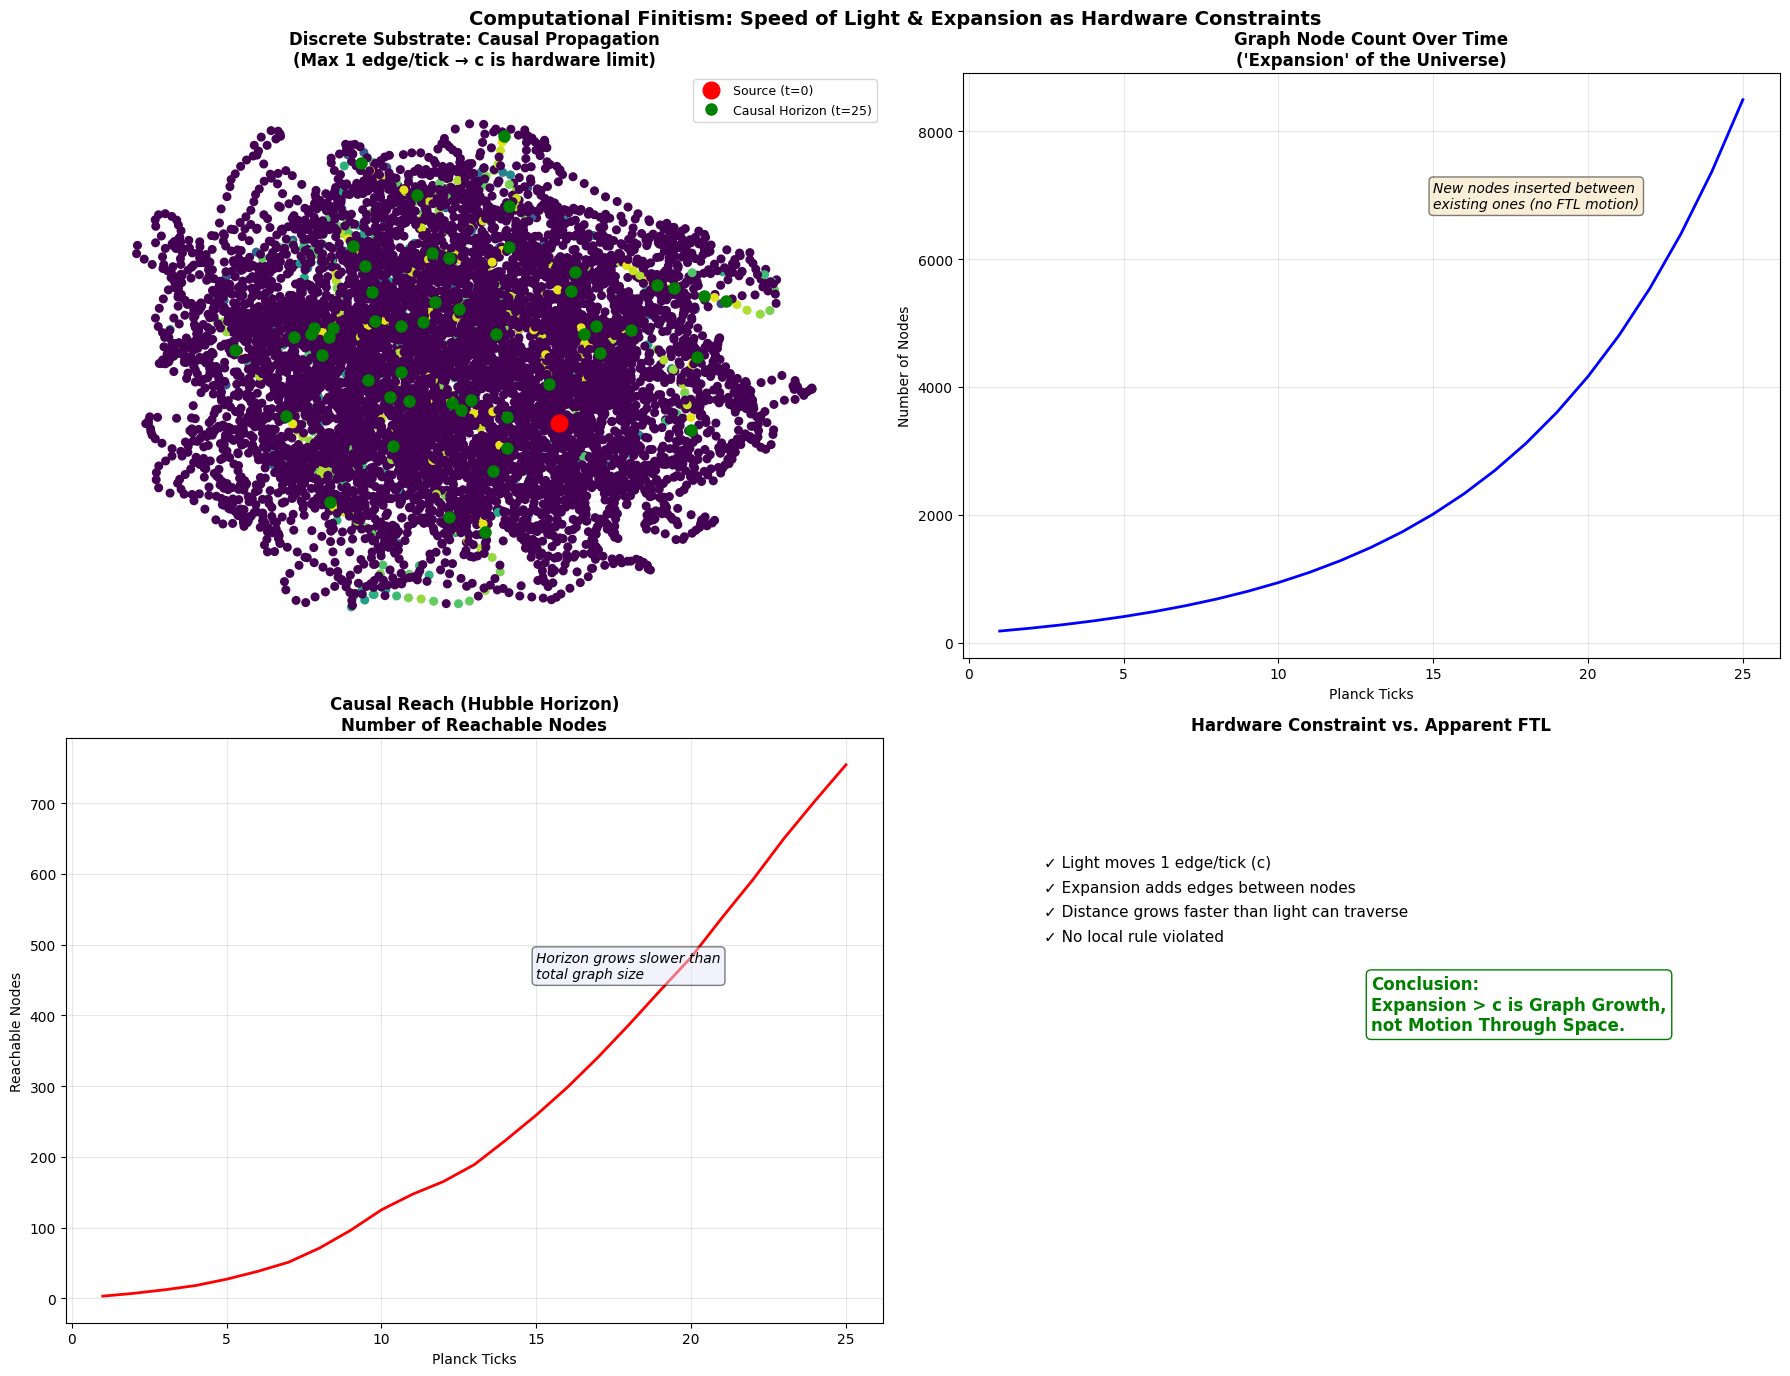


RESULTS
Final Nodes: 8492 (Expanded from 144)
Causal Reach: 754 nodes
Max Propagation Speed: 1 edge/tick (Hardware Limit)


In [6]:
"""
graph_causal_propagation.py
============================
Demonstrating Causal Propagation, Graph Expansion, and the Speed-of-Light Limit
in a Discrete Computational Substrate.

Shows:
1. Light propagates at exactly 1 edge per Planck tick (hardware constraint).
2. "Expansion > c" is graph node insertion, not motion through space.
3. Hubble horizon emerges as maximum reachable graph distance.
4. No FTL violation: local update rules are never broken.

Author: Néstor E. Ramos
For: "The Pixelated Universe" - Computational Substrate Section
"""

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.colors import Normalize
from matplotlib.cm import viridis
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("GRAPH CAUSAL PROPAGATION & EXPANSION (FINITIST FRAMEWORK)")
print("=" * 70)

# =============================================================================
# FINITIST CONSTANTS
# =============================================================================
PLANCK_TICK = 1.0
MAX_DIGIT = 9
TICKS = 25
GRID_SIZE = 12
EXPANSION_RATE = 0.15  # Fraction of edges that spawn new nodes per tick

# =============================================================================
# SIMULATION ENGINE
# =============================================================================

def simulate_causal_propagation(G, source=0, ticks=TICKS, expansion_rate=EXPANSION_RATE):
    """
    Simulate light propagation + graph expansion.
    - Propagation: BFS wavefront, max 1 edge/tick
    - Expansion: insert new nodes between existing edges
    """
    frontier = {source: 0}  # node: arrival_tick
    graph_states = []
    causal_distances = []
    total_nodes = []

    current_G = G.copy()
    node_counter = len(current_G.nodes())

    for t in range(1, ticks + 1):
        # 1. GRAPH EXPANSION (Insert new computational substrate)
        edges = list(current_G.edges())
        n_expand = int(len(edges) * expansion_rate)
        if n_expand > 0:
            # FIX: Use indices to select edges, not the edges directly
            edge_indices = np.random.choice(len(edges), size=n_expand, replace=False)
            expand_edges = [edges[i] for i in edge_indices]

            for u, v in expand_edges:
                new_node = node_counter
                node_counter += 1
                current_G.remove_edge(u, v)
                current_G.add_edge(u, new_node)
                current_G.add_edge(new_node, v)

        # 2. CAUSAL PROPAGATION (1 edge/tick limit)
        new_reached = {}
        for node, arrival in frontier.items():
            if arrival == t - 1:
                for neighbor in current_G.neighbors(node):
                    if neighbor not in frontier:
                        new_reached[neighbor] = t
        frontier.update(new_reached)

        # Record state
        graph_states.append(current_G.copy())
        causal_distances.append(len(frontier))
        total_nodes.append(len(current_G.nodes()))

    return graph_states, frontier, causal_distances, total_nodes

# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_causal_propagation(graph_states, frontier, causal_distances, total_nodes):
    print("\n[1/2] Rendering Causal Propagation & Expansion...")

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

    # --- Panel 1: Final Graph State + Propagation Wavefront ---
    final_G = graph_states[-1]
    pos = nx.spring_layout(final_G, seed=42, k=0.5)

    # Color nodes by arrival time (use 0 for unreached nodes for cmap compatibility)
    node_colors = [frontier.get(n, 0) for n in final_G.nodes()]

    # NetworkX uses vmin/vmax for colormaps, NOT norm
    nx.draw_networkx_nodes(final_G, pos, node_size=30,
                          node_color=node_colors, cmap=viridis,
                          vmin=0, vmax=TICKS, ax=ax1)
    nx.draw_networkx_edges(final_G, pos, edge_color='gray', alpha=0.2, width=0.5, ax=ax1)

    # Mark source and horizon
    ax1.plot(pos[0][0], pos[0][1], 'ro', markersize=12, label='Source (t=0)')
    horizon_nodes = [n for n, t in frontier.items() if t == TICKS]
    if horizon_nodes:
        hx = [pos[n][0] for n in horizon_nodes]
        hy = [pos[n][1] for n in horizon_nodes]
        ax1.plot(hx, hy, 'go', markersize=8, label='Causal Horizon (t=25)')

    ax1.set_title("Discrete Substrate: Causal Propagation\n(Max 1 edge/tick → c is hardware limit)",
                 fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.axis('off')

    # --- Panel 2: Graph Growth (Expansion) ---
    ax2.plot(range(1, TICKS+1), total_nodes, 'b-', linewidth=2)
    ax2.set_title("Graph Node Count Over Time\n('Expansion' of the Universe)", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Planck Ticks")
    ax2.set_ylabel("Number of Nodes")
    ax2.grid(True, alpha=0.3)
    ax2.text(15, max(total_nodes)*0.8, "New nodes inserted between\nexisting ones (no FTL motion)",
            fontsize=10, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # --- Panel 3: Causal Distance (Hubble Horizon) ---
    ax3.plot(range(1, TICKS+1), causal_distances, 'r-', linewidth=2)
    ax3.set_title("Causal Reach (Hubble Horizon)\nNumber of Reachable Nodes", fontsize=12, fontweight='bold')
    ax3.set_xlabel("Planck Ticks")
    ax3.set_ylabel("Reachable Nodes")
    ax3.grid(True, alpha=0.3)
    ax3.text(15, max(causal_distances)*0.6, "Horizon grows slower than\ntotal graph size",
            fontsize=10, style='italic', bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))

    # --- Panel 4: Conceptual Diagram ---
    ax4.axis('off')
    ax4.set_title("Hardware Constraint vs. Apparent FTL", fontsize=12, fontweight='bold')
    ax4.text(0.1, 0.8, "✓ Light moves 1 edge/tick (c)\n✓ Expansion adds edges between nodes\n✓ Distance grows faster than light can traverse\n✓ No local rule violated",
            fontsize=11, va='top', linespacing=1.8)
    ax4.text(0.5, 0.5, "Conclusion:\nExpansion > c is Graph Growth,\nnot Motion Through Space.",
            fontsize=12, fontweight='bold', color='green', bbox=dict(boxstyle='round', facecolor='white', edgecolor='green'))
    ax4.set_xlim(0, 1)
    ax4.set_ylim(0, 1)

    plt.suptitle("Computational Finitism: Speed of Light & Expansion as Hardware Constraints",
                fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()

    fig.savefig("graph_causal_propagation_finitist.png", dpi=300, bbox_inches='tight')
    print("  ✓ Saved: graph_causal_propagation_finitist.png")
    plt.show()

# =============================================================================
# MAIN EXECUTION
# =============================================================================

def main():
    G = build_initial_lattice()
    graph_states, frontier, causal_distances, total_nodes = simulate_causal_propagation(G)
    plot_causal_propagation(graph_states, frontier, causal_distances, total_nodes)

    print("\n" + "=" * 70)
    print("RESULTS")
    print("=" * 70)
    print(f"Final Nodes: {total_nodes[-1]} (Expanded from {len(G.nodes())})")
    print(f"Causal Reach: {len(frontier)} nodes")
    print(f"Max Propagation Speed: 1 edge/tick (Hardware Limit)")
    print("=" * 70)

if __name__ == "__main__":
    main()